In [1]:
from CST import CSTAirfoilParameterization
import pandas as pd
import numpy as np

> 8阶CST-LLM方法，没有复现LLM部分，直接使用原文中表现最好的特征函数: 0.5 ∗ x + 0.5 ∗ np.sign(x) ∗ np.abs(x) ∗∗ (1∕3)

In [2]:
cst_llm = CSTAirfoilParameterization(order=8, N1=0.5, N2=1.0, t_func=lambda x: x**7 + (1 - x)**7 * x + x * (1 - x) * (1 + x + x**2 + x**3 + x**4 + x**5) + 0.45 * x**2 * (1 - x)**2 * (1 + x + x**2 + x**3 + x**4) + 0.35 * x * (1 - x)**3 * (2 - x) * (1 + x + x**2 + x**3) + 0.25 * x**4 * (1 - x)**4 * (1 + x + x**2) + 0.2 * x**5 * (1 - x)**5 * (1 + x) + 0.18 * x**6 * (1 - x)**6)
cst = CSTAirfoilParameterization(order=8, N1=0.5, N2=1.0)

In [3]:
data_dir = 'data'
files = ['param.csv', 'x_lower.csv', 'x_upper.csv', 'z_lower.csv', 'z_upper.csv']

# 读取翼型数据
param = pd.read_csv(f'{data_dir}/param.csv')
x_lower_ = pd.read_csv(f'{data_dir}/x_lower.csv', header=None).to_numpy()
x_upper_ = pd.read_csv(f'{data_dir}/x_upper.csv', header=None).to_numpy()
z_lower_ = pd.read_csv(f'{data_dir}/z_lower.csv', header=None).to_numpy()
z_upper_ = pd.read_csv(f'{data_dir}/z_upper.csv', header=None).to_numpy()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


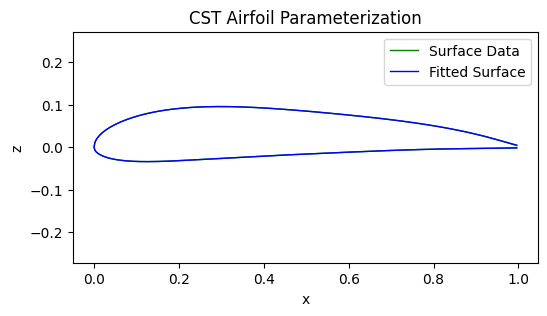

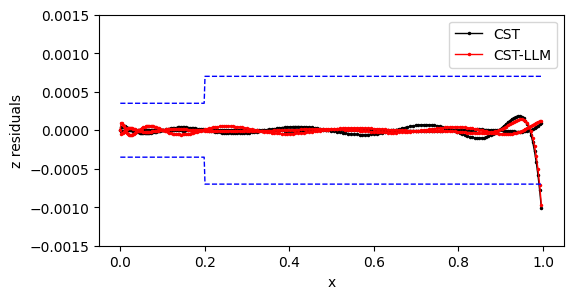

In [4]:
for i in range(1): 
    x_lower, z_lower, x_upper, z_upper = x_lower_[i][::-1], z_lower_[i][::-1], x_upper_[i], z_upper_[i]

    cst_llm.fit_airfoil(x_upper, z_upper)
    cst_llm.fit_airfoil(x_lower, z_lower, is_upper=False)

    cst.fit_airfoil(x_upper, z_upper)
    cst.fit_airfoil(x_lower, z_lower, is_upper=False)

    z_upper_pred = cst_llm.generate_airfoil(x_upper)
    z_lower_pred = cst_llm.generate_airfoil(x_lower, is_upper=False)

    z_upper_cst = cst.generate_airfoil(x_upper)
    z_lower_cst = cst.generate_airfoil(x_lower, is_upper=False)

    cst_llm.plot_airfoil(x_upper, z_upper, x_lower, z_lower, z_upper_pred, z_lower_pred)
    cst_llm.plot_residuals(x_upper, z_upper, x_lower, z_lower, z_upper_pred, z_lower_pred, z_upper_cst, z_lower_cst)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


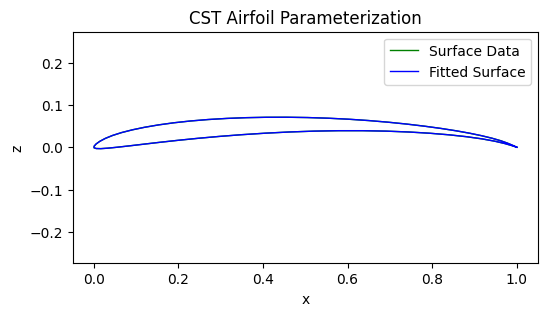

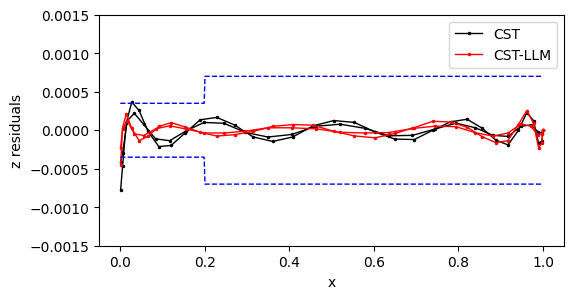

In [5]:
af = pd.read_csv(f'{data_dir}/e63.csv', header=None)
af_x = af.iloc[:, 0].to_numpy()
af_z = af.iloc[:, 1].to_numpy()

af_x_upper = af_x[:33][::-1]
af_z_upper = af_z[:33][::-1]
af_x_lower = af_x[33:]
af_z_lower = af_z[33:]

cst_llm.fit_airfoil(af_x_upper, af_z_upper)
cst_llm.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

cst.fit_airfoil(af_x_upper, af_z_upper)
cst.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

af_z_upper_pred = cst_llm.generate_airfoil(af_x_upper)
af_z_lower_pred = cst_llm.generate_airfoil(af_x_lower, is_upper=False)

af_z_upper_cst = cst.generate_airfoil(af_x_upper)
af_z_lower_cst = cst.generate_airfoil(af_x_lower, is_upper=False)

cst_llm.plot_airfoil(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred)
cst_llm.plot_residuals(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred, af_z_upper_cst, af_z_lower_cst)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


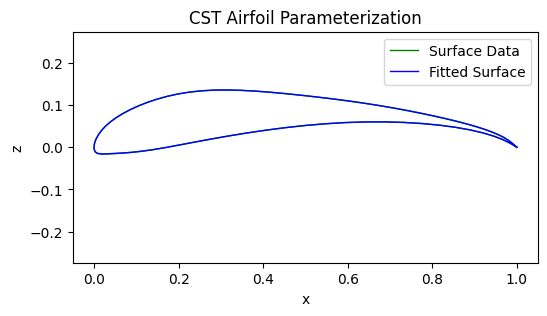

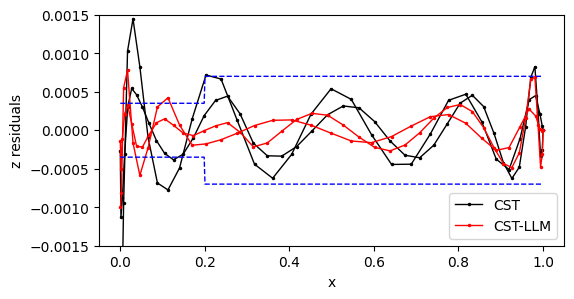

In [6]:
af = pd.read_csv(f'{data_dir}/s1223.csv', header=None)
af_x = af.iloc[:, 0].to_numpy()
af_z = af.iloc[:, 1].to_numpy()

af_x_upper = af_x[:46][::-1]
af_z_upper = af_z[:46][::-1]
af_x_lower = af_x[46:]
af_z_lower = af_z[46:]

cst_llm.fit_airfoil(af_x_upper, af_z_upper)
cst_llm.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

cst.fit_airfoil(af_x_upper, af_z_upper)
cst.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

af_z_upper_pred = cst_llm.generate_airfoil(af_x_upper)
af_z_lower_pred = cst_llm.generate_airfoil(af_x_lower, is_upper=False)

af_z_upper_cst = cst.generate_airfoil(af_x_upper)
af_z_lower_cst = cst.generate_airfoil(af_x_lower, is_upper=False)

cst_llm.plot_airfoil(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred)
cst_llm.plot_residuals(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred, af_z_upper_cst, af_z_lower_cst)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


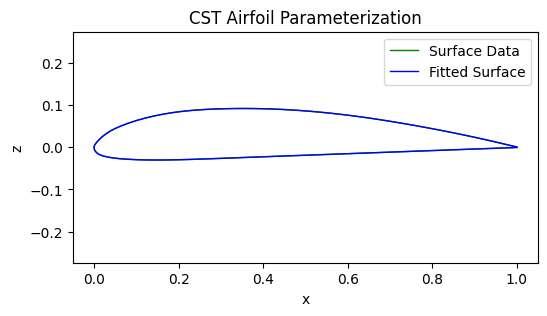

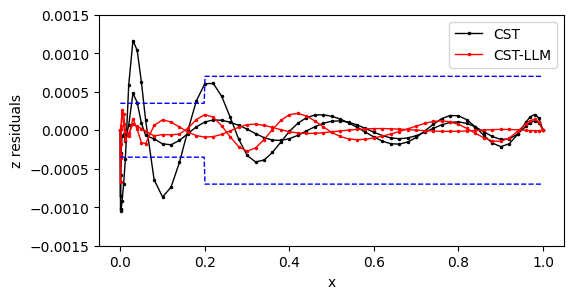

In [7]:
af = pd.read_csv(f'{data_dir}/clarky.csv', header=None)
af_x = af.iloc[:, 0].to_numpy()
af_z = af.iloc[:, 1].to_numpy()

af_x_upper = af_x[:61]
af_z_upper = af_z[:61]
af_x_lower = af_x[61:]
af_z_lower = af_z[61:]

cst_llm.fit_airfoil(af_x_upper, af_z_upper)
cst_llm.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

cst.fit_airfoil(af_x_upper, af_z_upper)
cst.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

af_z_upper_pred = cst_llm.generate_airfoil(af_x_upper)
af_z_lower_pred = cst_llm.generate_airfoil(af_x_lower, is_upper=False)

af_z_upper_cst = cst.generate_airfoil(af_x_upper)
af_z_lower_cst = cst.generate_airfoil(af_x_lower, is_upper=False)

cst_llm.plot_airfoil(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred)
cst_llm.plot_residuals(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred, af_z_upper_cst, af_z_lower_cst)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


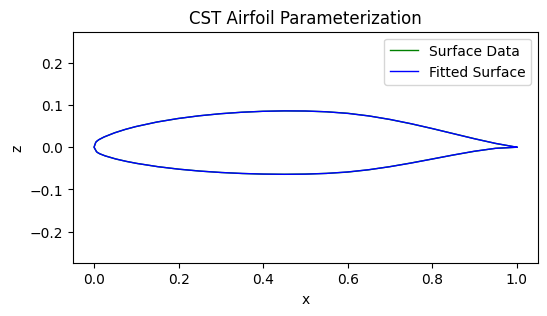

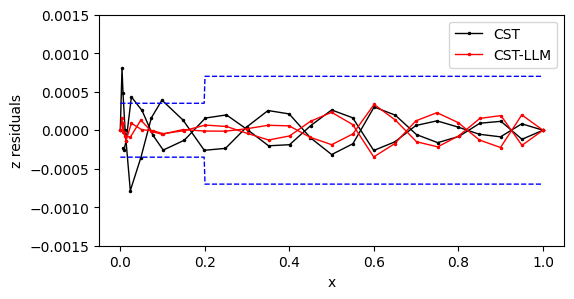

In [8]:
af = pd.read_csv(f'{data_dir}/naca66215.csv', header=None)
af_x = af.iloc[:, 0].to_numpy()
af_z = af.iloc[:, 1].to_numpy()

af_x_upper = af_x[:26][::-1]
af_z_upper = af_z[:26][::-1]
af_x_lower = af_x[26:]
af_z_lower = af_z[26:]

cst_llm.fit_airfoil(af_x_upper, af_z_upper)
cst_llm.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

cst.fit_airfoil(af_x_upper, af_z_upper)
cst.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

af_z_upper_pred = cst_llm.generate_airfoil(af_x_upper)
af_z_lower_pred = cst_llm.generate_airfoil(af_x_lower, is_upper=False)

af_z_upper_cst = cst.generate_airfoil(af_x_upper)
af_z_lower_cst = cst.generate_airfoil(af_x_lower, is_upper=False)

cst_llm.plot_airfoil(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred)
cst_llm.plot_residuals(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred, af_z_upper_cst, af_z_lower_cst)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


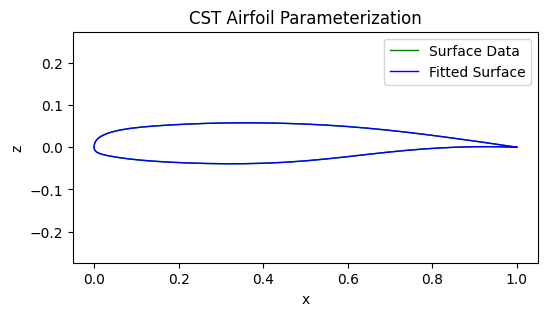

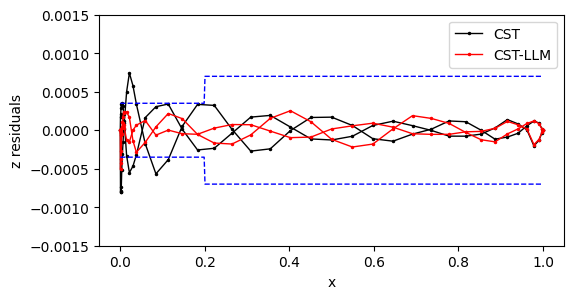

In [9]:
af = pd.read_csv(f'{data_dir}/rae5214.csv', header=None)
af_x = af.iloc[:, 0].to_numpy()
af_z = af.iloc[:, 1].to_numpy()

af_x_upper = af_x[:42]
af_z_upper = af_z[:42]
af_x_lower = af_x[42:]
af_z_lower = af_z[42:]

cst_llm.fit_airfoil(af_x_upper, af_z_upper)
cst_llm.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

cst.fit_airfoil(af_x_upper, af_z_upper)
cst.fit_airfoil(af_x_lower, af_z_lower, is_upper=False)

af_z_upper_pred = cst_llm.generate_airfoil(af_x_upper)
af_z_lower_pred = cst_llm.generate_airfoil(af_x_lower, is_upper=False)

af_z_upper_cst = cst.generate_airfoil(af_x_upper)
af_z_lower_cst = cst.generate_airfoil(af_x_lower, is_upper=False)

cst_llm.plot_airfoil(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred)
cst_llm.plot_residuals(af_x_upper, af_z_upper, af_x_lower, af_z_lower, af_z_upper_pred, af_z_lower_pred, af_z_upper_cst, af_z_lower_cst)